# Heart Disease 분류 모델링

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, accuracy_score
)

## 데이터 로드

In [24]:
# 로지스틱회귀용: 스케일링 적용본
train_scaled = pd.read_csv('dataset/heart_train_scaled.csv')
test_scaled = pd.read_csv('dataset/heart_test_scaled.csv')
X_train_lr = train_scaled.drop('HeartDisease', axis=1)
y_train_lr = train_scaled['HeartDisease']
X_test_lr = test_scaled.drop('HeartDisease', axis=1)
y_test_lr = test_scaled['HeartDisease']

# 랜덤포레스트용: 스케일링 안 한 원본(인코딩만 된 상태)
train_raw = pd.read_csv('dataset/heart_train.csv')
test_raw = pd.read_csv('dataset/heart_test.csv')
X_train_rf = train_raw.drop('HeartDisease', axis=1)
y_train_rf = train_raw['HeartDisease']
X_test_rf = test_raw.drop('HeartDisease', axis=1)
y_test_rf = test_raw['HeartDisease']

print(X_train_lr.shape, X_test_lr.shape, X_train_rf.shape, X_test_rf.shape)

(733, 15) (184, 15) (733, 15) (184, 15)


## 1. Logistic Regression (해석용 베이스라인)

In [25]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_lr, y_train_lr)

y_pred_lr = log_reg.predict(X_test_lr)
y_proba_lr = log_reg.predict_proba(X_test_lr)[:, 1]

print(classification_report(y_test_lr, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test_lr, y_proba_lr))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85        72
           1       0.92      0.88      0.90       112

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184

ROC-AUC: 0.9203869047619047


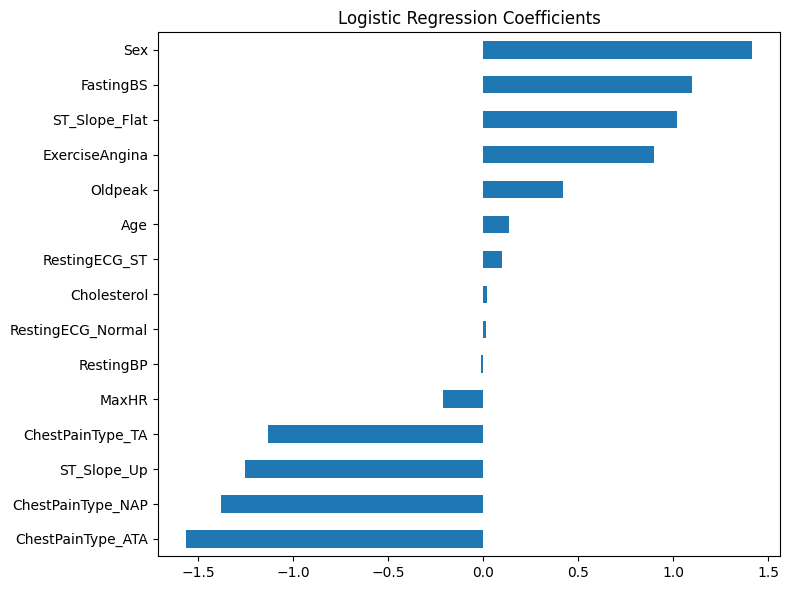

In [26]:
# 회귀 계수로 변수별 영향 방향/크기 확인
coef_df = pd.Series(log_reg.coef_[0], index=X_train_lr.columns).sort_values()

plt.figure(figsize=(8, 6))
coef_df.plot(kind='barh')
plt.title('Logistic Regression Coefficients')
plt.tight_layout()
plt.savefig('output/heart-figures/logreg_coefficients.png', dpi=120)
plt.show()

## 1-1. 스케일러 비교 (Logistic Regression)
전처리 단계에서 StandardScaler, MinMaxScaler, RobustScaler 3종으로 변환한 데이터를 모두 저장해두었다. 어떤 스케일러가 로지스틱회귀 성능에 가장 적합한지 비교한다.

In [27]:
# 스케일러별 데이터로 로지스틱회귀를 각각 학습시켜 Accuracy/ROC-AUC 비교
scaler_files = {
    'StandardScaler': ('dataset/heart_train_scaled.csv', 'dataset/heart_test_scaled.csv'),
    'MinMaxScaler': ('dataset/heart_train_minmax.csv', 'dataset/heart_test_minmax.csv'),
    'RobustScaler': ('dataset/heart_train_robust.csv', 'dataset/heart_test_robust.csv'),
}

scaler_lr_results = {}
for name, (train_path, test_path) in scaler_files.items():
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    X_tr = train.drop('HeartDisease', axis=1)
    y_tr = train['HeartDisease']
    X_te = test.drop('HeartDisease', axis=1)
    y_te = test['HeartDisease']

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    scaler_lr_results[name] = {
        'Accuracy': accuracy_score(y_te, pred),
        'ROC-AUC': roc_auc_score(y_te, proba),
    }

scaler_comparison = pd.DataFrame(scaler_lr_results).T.sort_values('ROC-AUC', ascending=False)
print(scaler_comparison)

                Accuracy   ROC-AUC
MinMaxScaler    0.875000  0.921751
StandardScaler  0.880435  0.920387
RobustScaler    0.880435  0.920387


## 2. Random Forest (성능용)

In [28]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_rf, y_train_rf)

y_pred_rf = rf.predict(X_test_rf)
y_proba_rf = rf.predict_proba(X_test_rf)[:, 1]

print(classification_report(y_test_rf, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test_rf, y_proba_rf))

              precision    recall  f1-score   support

           0       0.86      0.83      0.85        72
           1       0.89      0.91      0.90       112

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184

ROC-AUC: 0.9293774801587302


In [29]:
# 하이퍼파라미터 튜닝
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 8, 12, None],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
grid_search.fit(X_train_rf, y_train_rf)

print('Best params:', grid_search.best_params_)
rf_best = grid_search.best_estimator_

y_pred_rf_best = rf_best.predict(X_test_rf)
y_proba_rf_best = rf_best.predict_proba(X_test_rf)[:, 1]

print(classification_report(y_test_rf, y_pred_rf_best))
print('ROC-AUC:', roc_auc_score(y_test_rf, y_proba_rf_best))

Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.86      0.83      0.85        72
           1       0.89      0.91      0.90       112

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184

ROC-AUC: 0.9293774801587302


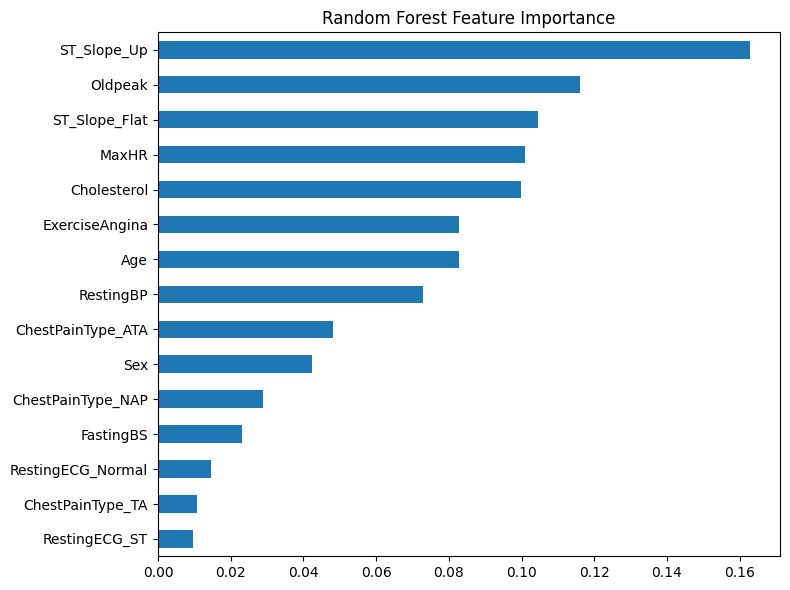

In [30]:
importance = pd.Series(rf_best.feature_importances_, index=X_train_rf.columns).sort_values()

plt.figure(figsize=(8, 6))
importance.plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('output/heart-figures/rf_feature_importance.png', dpi=120)
plt.show()

## 3. Boosting 계열 모델 (GradientBoosting / XGBoost / LightGBM)

In [31]:
boosting_models = {
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbosity=-1),
}

boosting_results = {}

for name, model in boosting_models.items():
    model.fit(X_train_rf, y_train_rf)
    y_pred = model.predict(X_test_rf)
    y_proba = model.predict_proba(X_test_rf)[:, 1]
    boosting_results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Accuracy': accuracy_score(y_test_rf, y_pred),
        'ROC-AUC': roc_auc_score(y_test_rf, y_proba),
    }
    print(f'--- {name} ---')
    print(classification_report(y_test_rf, y_pred))
    print('ROC-AUC:', boosting_results[name]['ROC-AUC'])
    print()

--- GradientBoosting ---
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        72
           1       0.90      0.93      0.91       112

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC: 0.9371279761904762

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.85      0.83      0.84        72
           1       0.89      0.90      0.90       112

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184

ROC-AUC: 0.9305555555555556

--- LightGBM ---
              precision    recall  f1-score   support

           0       0.86      0.89      0.88        72
           1       0.93      0.91      0.92       112

    accuracy                           0.90       184
   macro avg

## 4. 모델 비교

In [32]:
comparison = pd.DataFrame({
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test_lr, y_pred_lr),
        'ROC-AUC': roc_auc_score(y_test_lr, y_proba_lr),
    },
    'Random Forest (tuned)': {
        'Accuracy': accuracy_score(y_test_rf, y_pred_rf_best),
        'ROC-AUC': roc_auc_score(y_test_rf, y_proba_rf_best),
    },
    **{
        name: {'Accuracy': res['Accuracy'], 'ROC-AUC': res['ROC-AUC']}
        for name, res in boosting_results.items()
    },
}).T.sort_values('ROC-AUC', ascending=False)

comparison

,Accuracy,ROC-AUC
LightGBM,0.902174,0.945064
GradientBoosting,0.891304,0.937128
XGBoost,0.875000,0.930556
Random Forest (tuned),0.880435,0.929377
Logistic Regression,0.880435,0.920387


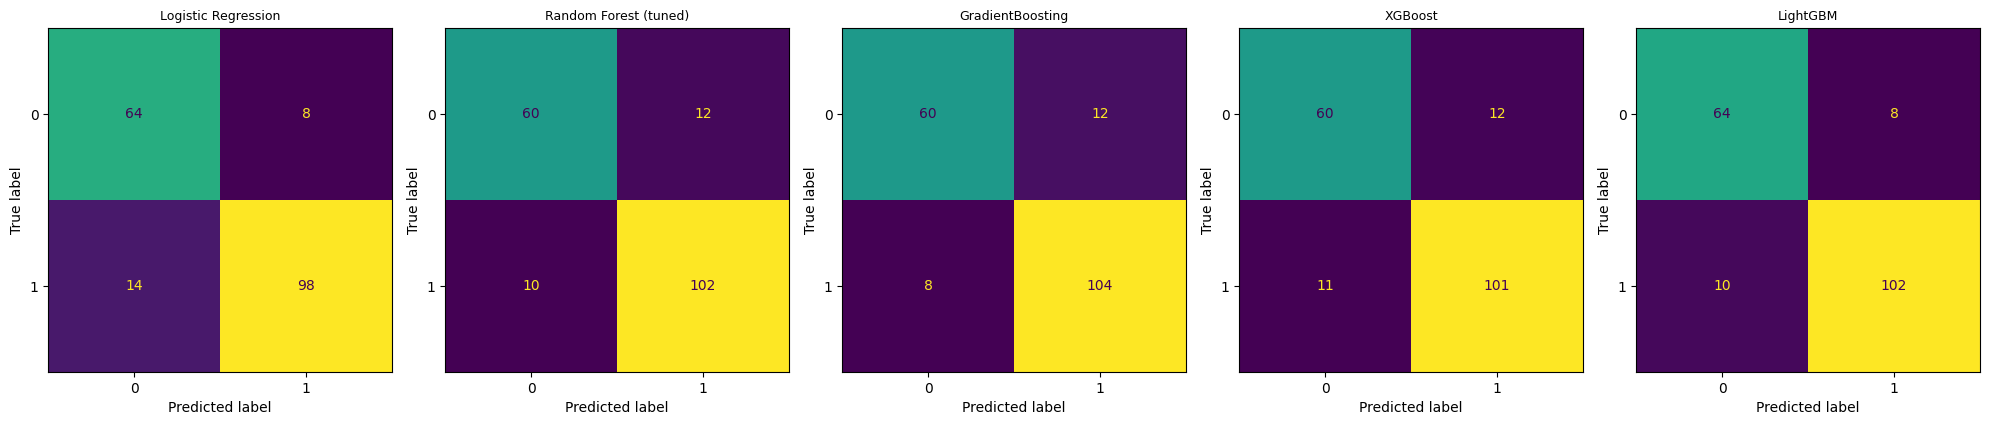

In [33]:
all_preds = {
    'Logistic Regression': y_pred_lr,
    'Random Forest (tuned)': y_pred_rf_best,
    **{name: res['y_pred'] for name, res in boosting_results.items()},
}
all_true = {
    'Logistic Regression': y_test_lr,
    'Random Forest (tuned)': y_test_rf,
    **{name: y_test_rf for name in boosting_results},
}

fig, axes = plt.subplots(1, len(all_preds), figsize=(4 * len(all_preds), 4))
for ax, name in zip(axes, all_preds):
    ConfusionMatrixDisplay.from_predictions(all_true[name], all_preds[name], ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.savefig('output/heart-figures/confusion_matrices.png', dpi=120)
plt.show()

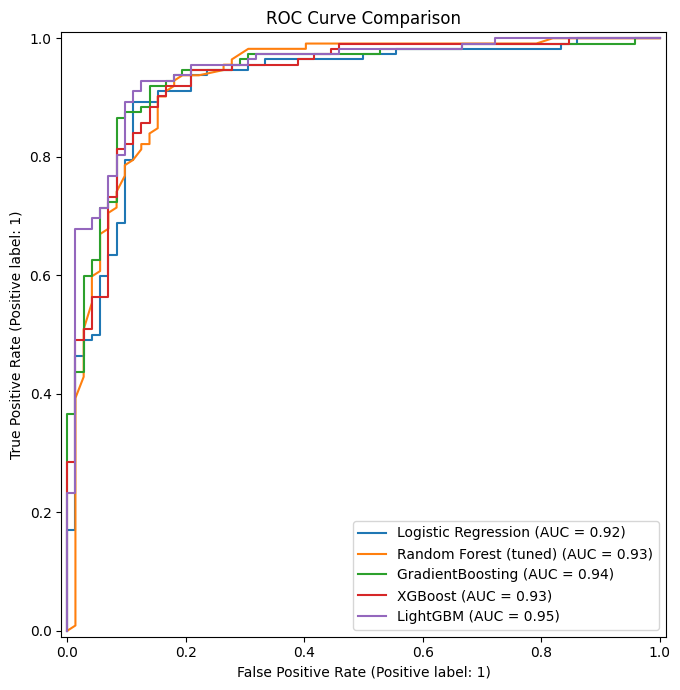

In [34]:
all_probas = {
    'Logistic Regression': y_proba_lr,
    'Random Forest (tuned)': y_proba_rf_best,
    **{name: res['y_proba'] for name, res in boosting_results.items()},
}

fig, ax = plt.subplots(figsize=(7, 7))
for name, proba in all_probas.items():
    true_y = y_test_lr if name == 'Logistic Regression' else y_test_rf
    RocCurveDisplay.from_predictions(true_y, proba, ax=ax, name=name)
ax.set_title('ROC Curve Comparison')
plt.tight_layout()
plt.savefig('output/heart-figures/roc_curve_comparison.png', dpi=120)
plt.show()